# Rice Variety Classification using Convolutional Neural Networks

## Objective

The objective of this project is to classify different varieties of rice grains using a Convolutional Neural Network (CNN).

The model is trained using TensorFlow and Keras on a labeled image dataset containing five rice varieties. After training, the model predicts the variety of an unseen rice grain image.

This notebook includes:

- Dataset preparation
- Image preprocessing
- CNN model development
- Model training
- Performance evaluation
- Prediction on new images


In [1]:

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from sklearn.metrics import classification_report


## Loading the Dataset

The Rice Image Dataset contains five different rice varieties.

- Arborio
- Basmati
- Ipsala
- Jasmine
- Karacadag

Images are resized to 128×128 pixels before training.




In [8]:
IMG_SIZE=(128,128)

BATCH_SIZE=32
train_datagen=ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)
train_generator=train_datagen.flow_from_directory(

"dataset/Rice_Image_Dataset",

target_size=IMG_SIZE,

batch_size=BATCH_SIZE,

class_mode="categorical",

subset="training"

)

validation_generator=train_datagen.flow_from_directory(

r"C:\Users\Lenovo_owner\OneDrive\Documents\AI_Developer_Toolkit\JUPITER\3_rice_classify\dataset\Rice_Image_Dataset",

target_size=IMG_SIZE,

batch_size=BATCH_SIZE,

class_mode="categorical",

subset="validation"

)

print(train_generator.class_indices)


Found 39445 images belonging to 5 classes.
Found 9860 images belonging to 5 classes.
{'Arborio': 0, 'Basmati': 1, 'Ipsala': 2, 'Jasmine': 3, 'Karacadag': 4}


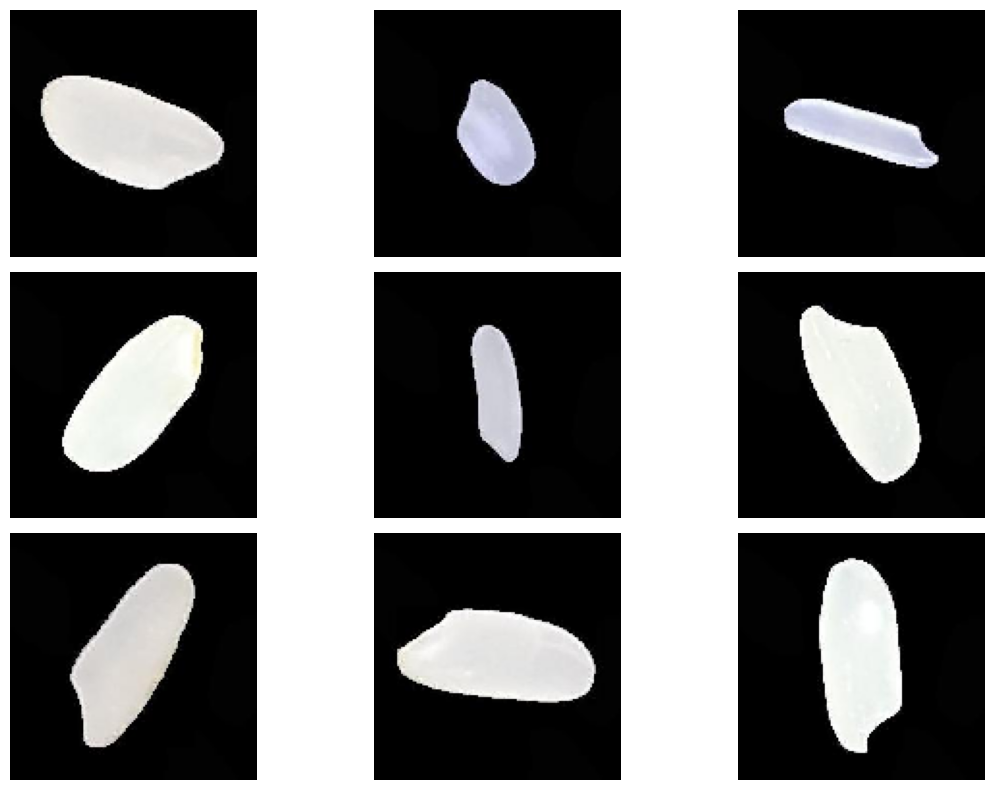

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,517,317 (24.86 MB)

 Trainable params: 6,517,317 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
#visualisation
images,labels=next(train_generator)

plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.axis("off")

plt.tight_layout()

plt.show()

## Building the CNN Model

model=Sequential([
tf.keras.layers.Input(shape=(128,128,3)),

Conv2D(32,(3,3),activation="relu"),

MaxPooling2D(),

Conv2D(64,(3,3),activation="relu"),

MaxPooling2D(),

Conv2D(128,(3,3),activation="relu"),

MaxPooling2D(),

Flatten(),

Dense(256,activation="relu"),

Dropout(0.5),

Dense(5,activation="softmax")
])

model.compile(

optimizer="adam",

loss="categorical_crossentropy",

metrics=["accuracy"]

)

model.summary()

Epoch 1/5
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 2486s 2s/step - accuracy: 0.9475 - loss: 0.1500 - val_accuracy: 0.9742 - val_loss: 0.0840
Epoch 2/5
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 485s 393ms/step - accuracy: 0.9730 - loss: 0.0824 - val_accuracy: 0.9918 - val_loss: 0.0257
Epoch 3/5
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 512s 415ms/step - accuracy: 0.9864 - loss: 0.0428 - val_accuracy: 0.9940 - val_loss: 0.0190
Epoch 4/5
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 411s 333ms/step - accuracy: 0.9908 - loss: 0.0289 - val_accuracy: 0.9972 - val_loss: 0.0086
Epoch 5/5
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 553s 448ms/step - accuracy: 0.9929 - loss: 0.0239 - val_accuracy: 0.9952 - val_loss: 0.0161


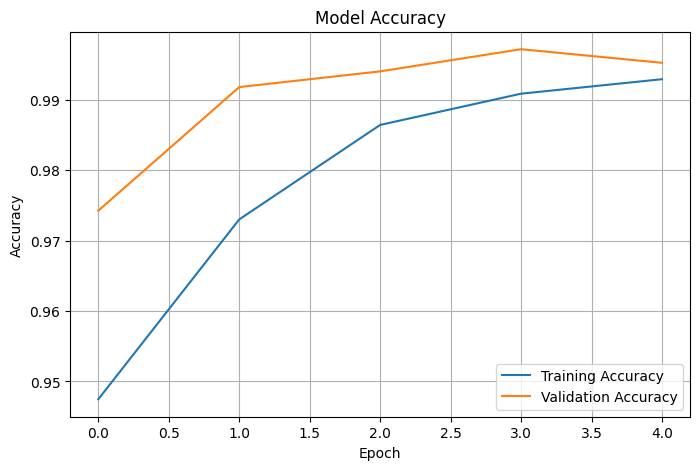

In [10]:
## Training the CNN Model

#The CNN model is trained using the training dataset for multiple epochs. During training, the model learns meaningful image features that help distinguish different rice varieties.

#Validation accuracy is monitored after every epoch to evaluate how well the model generalizes to unseen images.

history = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=5

)

## Training Performance

#The following graphs illustrate the model's learning behaviour during training.

#The accuracy graph shows how prediction performance improves over epochs, while the loss graph indicates how the prediction error decreases.

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"],label="Training Accuracy")

plt.plot(history.history["val_accuracy"],label="Validation Accuracy")

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()


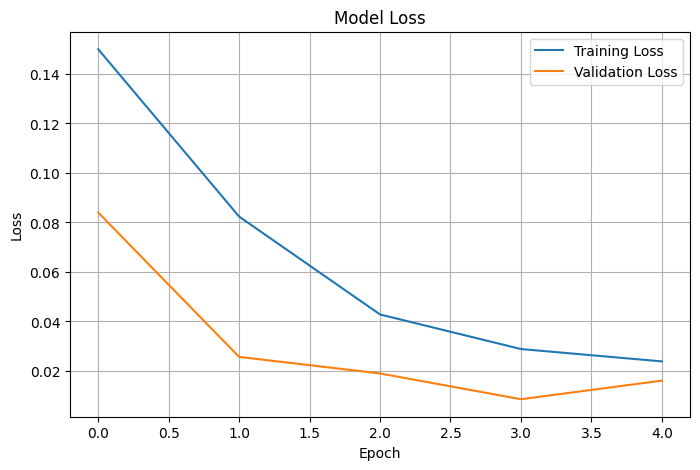

In [11]:

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"],label="Training Loss")

plt.plot(history.history["val_loss"],label="Validation Loss")

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()


In [12]:

## Evaluating the Model

#The trained CNN is evaluated on the validation dataset to measure its classification performance.

loss,accuracy=model.evaluate(validation_generator)

print("Validation Loss :",round(loss,4))

print("Validation Accuracy :",round(accuracy*100,2),"%")

predictions=model.predict(validation_generator)

predicted_classes=np.argmax(predictions,axis=1)

true_classes=validation_generator.classes

class_names=list(validation_generator.class_indices.keys())

print(

classification_report(

true_classes,

predicted_classes,

target_names=class_names

)

)


309/309 ━━━━━━━━━━━━━━━━━━━━ 32s 104ms/step - accuracy: 0.9952 - loss: 0.0161
Validation Loss : 0.0161
Validation Accuracy : 99.52 %
309/309 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/step
              precision    recall  f1-score   support

     Arborio       0.04      0.04      0.04       362
     Basmati       0.20      0.20      0.20      1963
      Ipsala       0.30      0.30      0.30      3000
     Jasmine       0.20      0.20      0.20      1899
   Karacadag       0.26      0.27      0.26      2636

    accuracy                           0.24      9860
   macro avg       0.20      0.20      0.20      9860
weighted avg       0.24      0.24      0.24      9860



In [1]:

plt.figure(figsize=(7,5))

plt.bar(

class_names,

validation_generator.samples*np.ones(len(class_names))/len(class_names)

)

plt.title("Rice Classes")

plt.xlabel("Rice Variety")

plt.ylabel("Approximate Samples")

plt.xticks(rotation=20)

plt.show()


model.save("model.keras")

print("Model saved successfully.")


NameError: name 'plt' is not defined

In [ ]:

## Testing on a New Image

#The trained model can now classify an unseen rice grain image by predicting the most probable rice variety.

from tensorflow.keras.preprocessing import image

img=image.load_img(

"sample.jpg",

target_size=(128,128)

)

img_array=image.img_to_array(img)

img_array=img_array/255.0

img_array=np.expand_dims(img_array,axis=0)

prediction=model.predict(img_array)

predicted_index=np.argmax(prediction)

print("Predicted Rice Variety :",class_names[predicted_index])

print("Confidence :",round(np.max(prediction)*100,2),"%")

#Replace "sample.jpg" with the path to any rice image you want to test.



# Conclusion

In this project, a Convolutional Neural Network (CNN) was developed using TensorFlow to classify five rice varieties from image data.

The dataset was preprocessed using image rescaling and validation splitting. The trained CNN achieved high validation accuracy, demonstrating its ability to distinguish rice varieties effectively.

This project highlights the usefulness of deep learning techniques in agricultural image classification and